In [29]:
# Download
from DATALAKE.data import *
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import matplotlib.pyplot as plt
from statsmodels.iolib.summary2 import summary_col
import sys
import os
sys.path.append("../dorian_code")

data_detrended = import_parquet('main_detrended')


In [30]:
data_detrended.tail(10)
for a in data_detrended.columns:
    print(a)

year
gdp_nominal
expected_inflation
taux_changes
cpi
taux_directeur
export
import
yield_perpetual
oil_price
gdp_cycle
gdp_trend
output_gap
taux_changes_stat
yield_perpetual_stat
gdp_nominal_stat
cpi_stat
export_stat
import_stat
oil_price_stat
gdp_trend_stat
gdp_trend_stat_stat
import_stat_stat


### Cost function in f(t)

We denote the cost function : 
$ 
L = 1/2 [\alpha_y(Y_t - y^*)^2 + \alpha_w(\pi_t - \pi_t^a)^2 + \alpha_e (\Delta e_t )^2]
$ 

In [31]:
data_detrended = data_detrended.set_index('year')

year
1862.0    2.640908e+02
1863.0    4.504496e+03
1864.0    5.465265e+02
1865.0    5.290192e+03
1866.0    5.142056e+03
              ...     
2018.0    2.075617e+03
2019.0    3.688893e+07
2020.0    2.410569e+03
2023.0    2.195172e+03
2024.0    2.234511e+02
Name: social_cost, Length: 105, dtype: float64

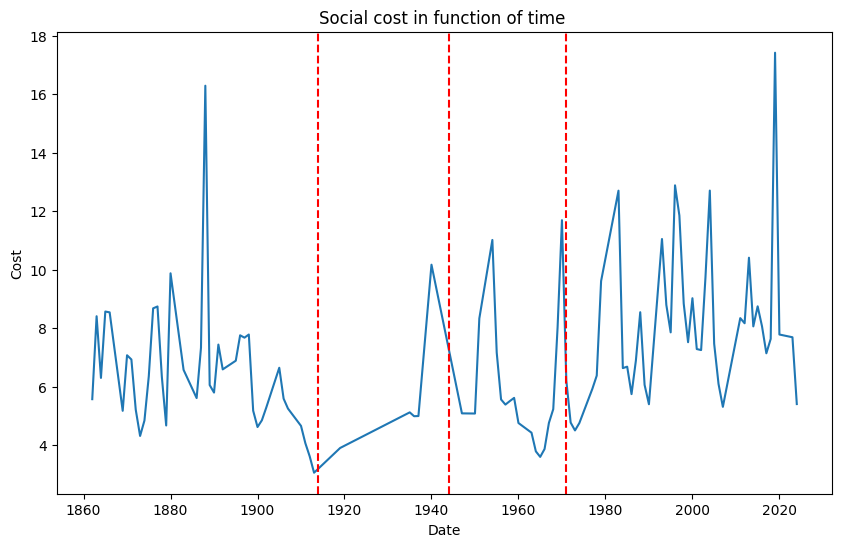

In [32]:
import numpy as np

#PLOT
data_detrended['social_cost'] = ( 0.5 * data_detrended['output_gap']**2 + 0.4 * (data_detrended['cpi_stat'] - data_detrended["expected_inflation"])**2 + 0.1 * data_detrended['taux_changes_stat']**2)
display(data_detrended['social_cost'])

np.log(data_detrended['social_cost']).plot(figsize=(10,6))

plt.title("Social cost in function of time ")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Cost")
plt.show()


/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


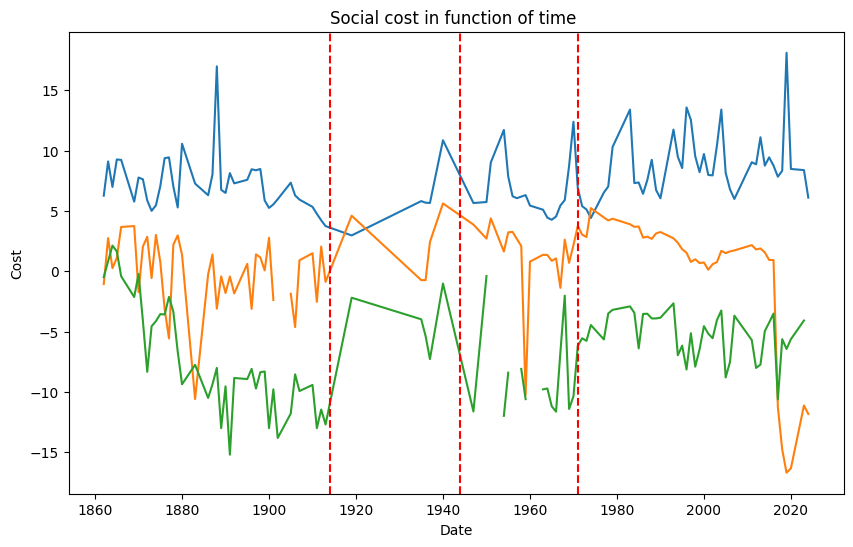

In [33]:
np.log(data_detrended['output_gap']**2).plot(figsize=(10,6))
np.log((data_detrended['cpi_stat'] - data_detrended["expected_inflation"])**2).plot(figsize=(10,6))
np.log(data_detrended['taux_changes_stat']**2).plot(figsize=(10,6))


plt.title("Social cost in function of time ")
plt.axvline(x=1914, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1944, color='red', linestyle='--', label='Seuil')
plt.axvline(x=1971, color='red', linestyle='--', label='Seuil')
plt.xlabel("Date")
plt.ylabel("Cost")
plt.show()

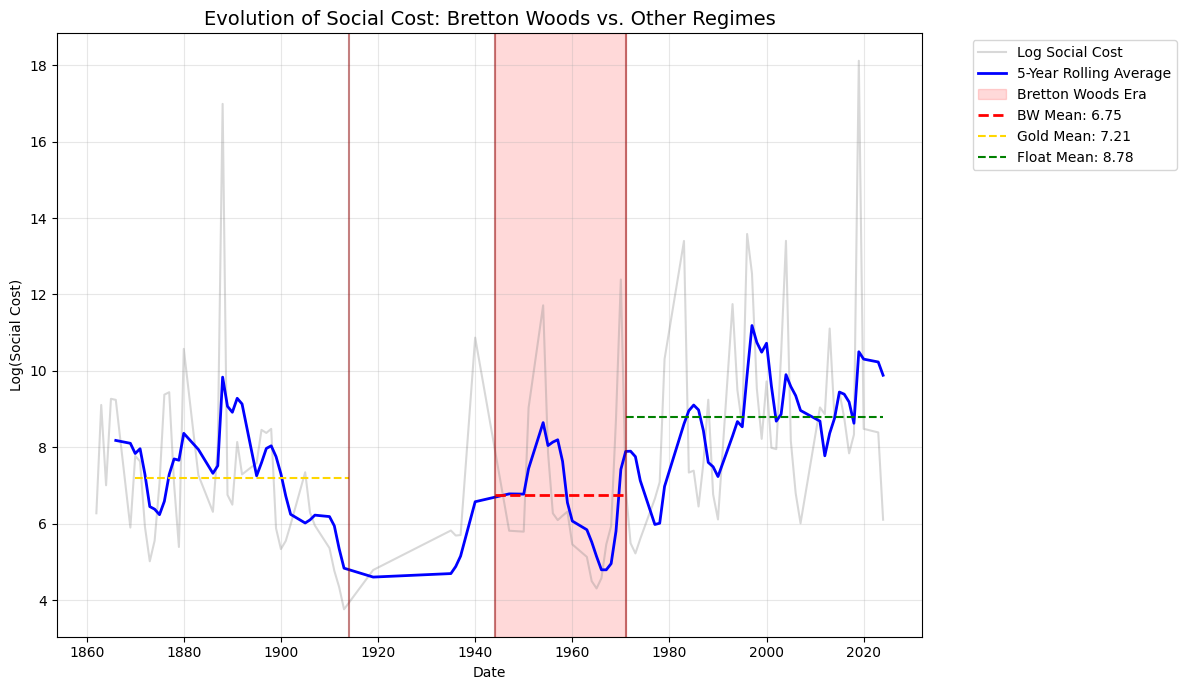

In [ ]:
########### MADE BY CHAT WARNING ###########
import matplotlib.pyplot as plt
import numpy as np

data_detrended = import_parquet('main_detrended')

# 1. Compute the Social Cost with your specific formula
data_detrended['social_cost'] = (
    data_detrended['output_gap']**2 + 
    (data_detrended['cpi_stat'] - data_detrended["expected_inflation"])**2 + 
    data_detrended['taux_changes_stat']**2
)

# Apply Log as in your example to manage scale
data_detrended['log_social_cost'] = np.log(data_detrended['social_cost'])

# 2. Calculate Mean Costs for each period to prove the hypothesis
cost_gold = data_detrended[data_detrended['year'] < 1914]['log_social_cost'].mean()
cost_interwar = data_detrended[(data_detrended['year'] >= 1914) & (data_detrended['year'] < 1944)]['log_social_cost'].mean()
cost_bw = data_detrended[(data_detrended['year'] >= 1944) & (data_detrended['year'] < 1971)]['log_social_cost'].mean()
cost_float = data_detrended[data_detrended['year'] >= 1971]['log_social_cost'].mean()

# 3. Visualization
plt.figure(figsize=(12, 7))

# Plot the raw log-cost and a smoothed version (5-year rolling) for clarity
plt.plot(data_detrended['year'], data_detrended['log_social_cost'], alpha=0.3, label="Log Social Cost", color='gray')
plt.plot(data_detrended['year'], data_detrended['log_social_cost'].rolling(window=5).mean(), 
         color='blue', lw=2, label="5-Year Rolling Average")

# Highlight Bretton Woods to show it is "higher"
plt.axvspan(1944, 1971, color='red', alpha=0.15, label='Bretton Woods Era')

# Add Horizontal Mean Lines to visually compare the levels
plt.hlines(y=cost_bw, xmin=1944, xmax=1971, color='red', linestyle='--', lw=2, label=f'BW Mean: {cost_bw:.2f}')
plt.hlines(y=cost_gold, xmin=1870, xmax=1914, color='gold', linestyle='--', label=f'Gold Mean: {cost_gold:.2f}')
plt.hlines(y=cost_float, xmin=1971, xmax=2024, color='green', linestyle='--', label=f'Float Mean: {cost_float:.2f}')

# Vertical dividers
for year in [1914, 1944, 1971]:
    plt.axvline(x=year, color='darkred', linestyle='-', alpha=0.5)

plt.title("Evolution of Social Cost: Bretton Woods vs. Other Regimes", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Log(Social Cost)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()